# 03 · Blog / article corpus
Polite fetch (robots.txt honoured, 1.5s delay, cached). Only **derived** data is kept: cost figures, activity tags and a ≤450-char attributed snippet. Code: `ml/scrape/blogs.py`.

No search-API key was available, so pages are fetched from direct article URL patterns (Holidify place pages).

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = r"C:\xampp\htdocs\travel_journel"
os.chdir(ROOT); sys.path.insert(0, ROOT)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": .3})
DATA = os.path.join(ROOT, "ml", "data")

In [2]:
bp, cp = f"{DATA}/blog_entries.json", f"{DATA}/blog_cost_obs.json"
B = pd.DataFrame(json.load(open(bp, encoding="utf8"))) if os.path.exists(bp) else pd.DataFrame()
BC = pd.DataFrame(json.load(open(cp, encoding="utf8"))) if os.path.exists(cp) else pd.DataFrame()
print(len(B), "blog snippets;", len(BC), "daily-cost observations;", B.destination.nunique() if len(B) else 0, "destinations")
B.head(5)[["destination","url","text"]] if len(B) else "no blog data yet"

196 blog snippets; 1 daily-cost observations; 101 destinations


,destination,url,text
0,"Kozhikode, India",https://www.holidify.com/places/kozhikode/,Vasco da Gama had set his foot on the remote beach of Kappad in Ko...
1,"Kozhikode, India",https://www.holidify.com/places/kozhikode/sightseeing-and-things-t...,Kozhikode Beach\n1 km from city center\nBeach\n3. Backwaters in Ko...
2,"Siliguri, India",https://www.holidify.com/places/siliguri/,"The Jaldapara National Park, situated on the banks of the Torsa ri..."
3,"Siliguri, India",https://www.holidify.com/places/siliguri/sightseeing-and-things-to...,Hong Kong Market\n1 km from city center\nTop Hotels In Siliguri\n4...
4,"Mysore, India",https://www.holidify.com/places/mysore/,"Located in the foothills of the Chamundi Hills, Mysore is the thir..."


destinations with both sources: 1 | median ratio blog/listing: 1.03


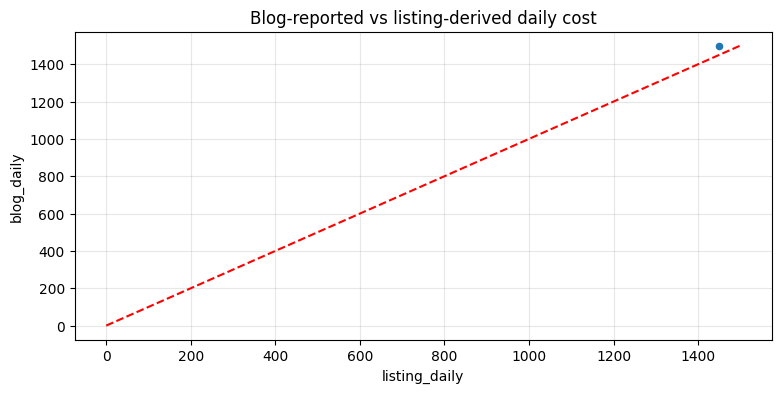

In [3]:
if len(BC):
    C = pd.DataFrame(json.load(open(f"{DATA}/india_catalog.json", encoding="utf8")))
    m = BC.groupby("destination").daily_inr.median().rename("blog_daily").to_frame().join(C.set_index("name").base_daily_inr.rename("listing_daily"), how="inner")
    print("destinations with both sources:", len(m), "| median ratio blog/listing:", round((m.blog_daily/m.listing_daily).median(),2))
    m.plot.scatter("listing_daily","blog_daily", title="Blog-reported vs listing-derived daily cost"); plt.plot([0,m.max().max()],[0,m.max().max()],"r--"); plt.show()